**STEP 1 - Load Dataset**

In [2]:
import pandas as pd

file_path = '/content/sample_data/Forecasting Case- Study.xlsx'

df = pd.read_excel(file_path)

print(df.head())
print(df.columns)

        State                 Date        Total   Category
0     Alabama  2019-01-12 00:00:00  109574036.0  Beverages
1     Arizona  2019-01-12 00:00:00  109101594.6  Beverages
2    Arkansas  2019-01-12 00:00:00   58049432.2  Beverages
3  California  2019-01-12 00:00:00  444766890.6  Beverages
4    Colorado  2019-01-12 00:00:00   89816716.3  Beverages
Index(['State', 'Date', 'Total', 'Category'], dtype='object')


**STEP 2 - Data Cleaning**

In [3]:
df['Date'] = pd.to_datetime(df['Date'])

In [4]:
df = df.sort_values(['State', 'Date'])

Handle Missing Date

In [5]:
all_states = []

for state in df['State'].unique():
    temp = df[df['State'] == state].copy()

    temp = temp.set_index('Date')

    temp = temp.asfreq('D')

    temp['State'] = state

    temp['Total'] = temp['Total'].interpolate()

    all_states.append(temp.reset_index())
df = pd.concat(all_states)

Handle Missing values

In [6]:
print(df.isnull().sum())

# Fill remaining nulls

df['Category'] = df['Category'].bfill()

Date            0
State           0
Total           0
Category    68757
dtype: int64


**STEP 3 - Exploratory Data Analysis**

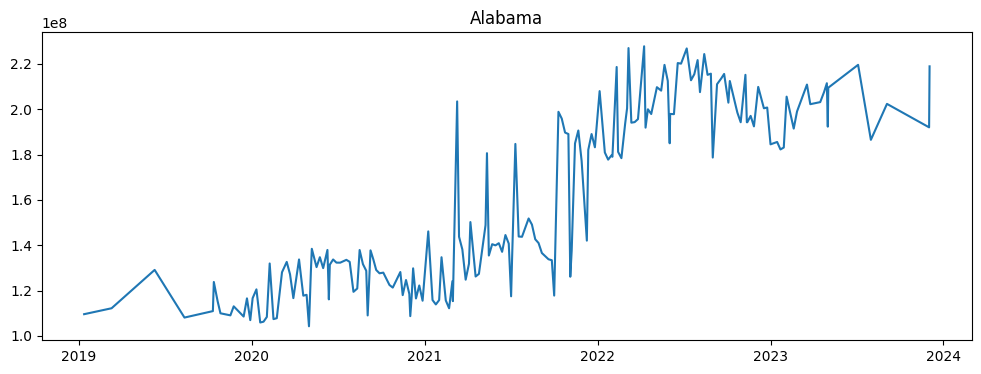

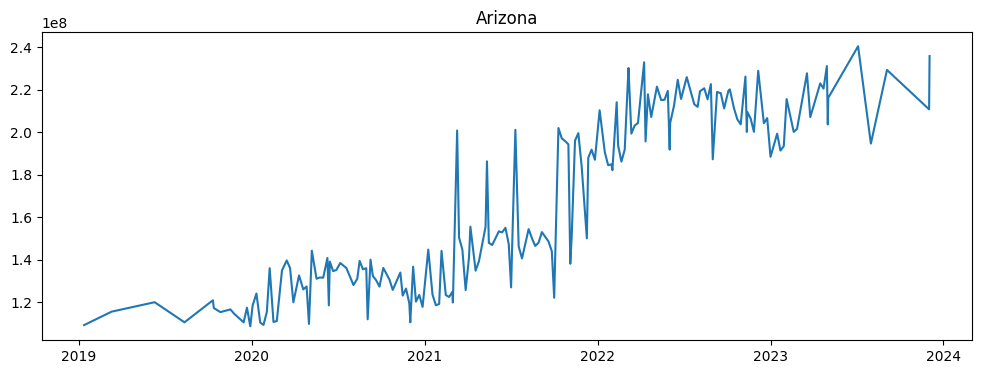

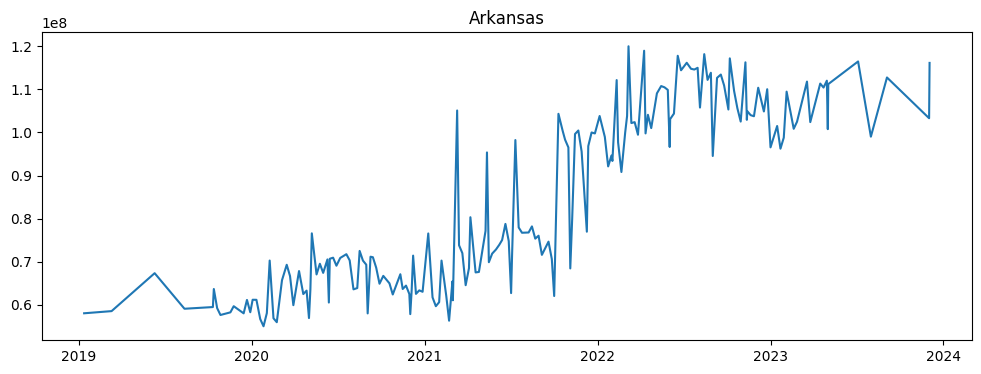

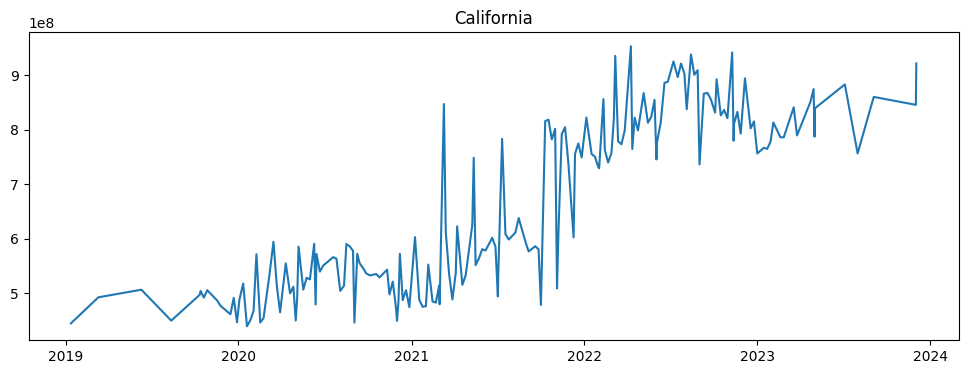

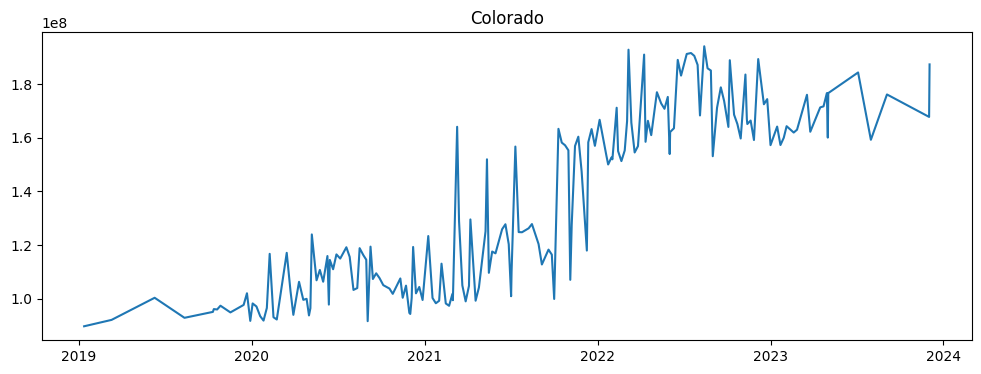

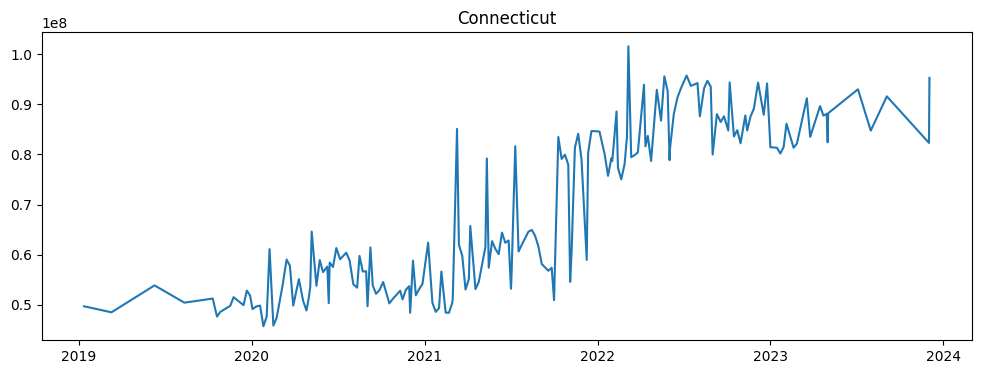

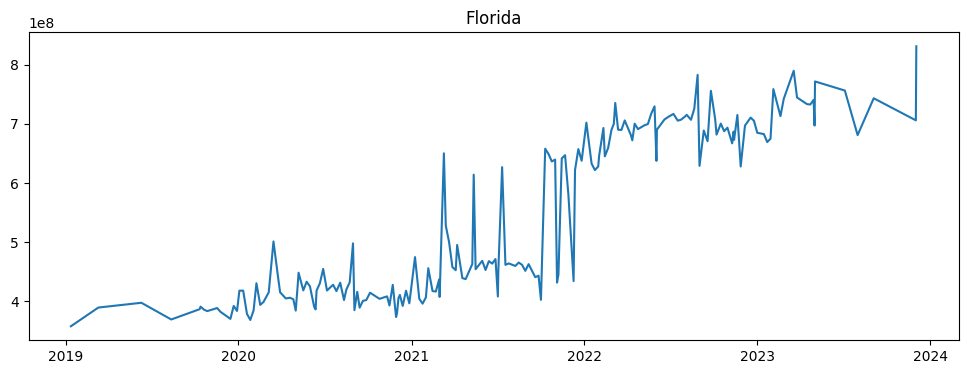

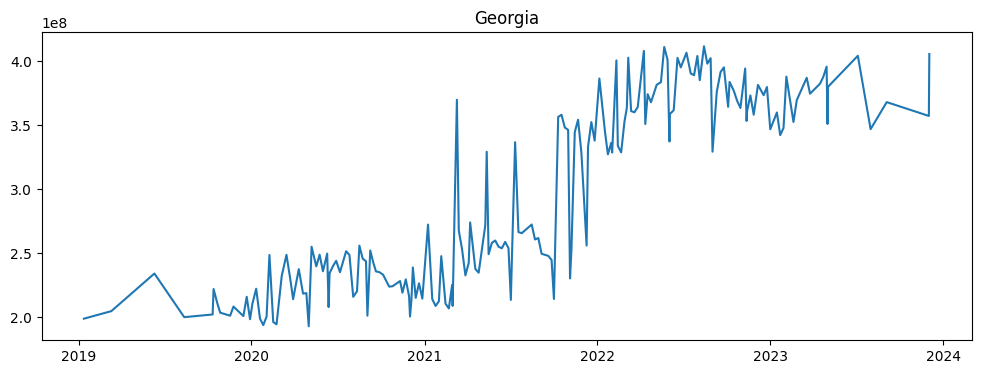

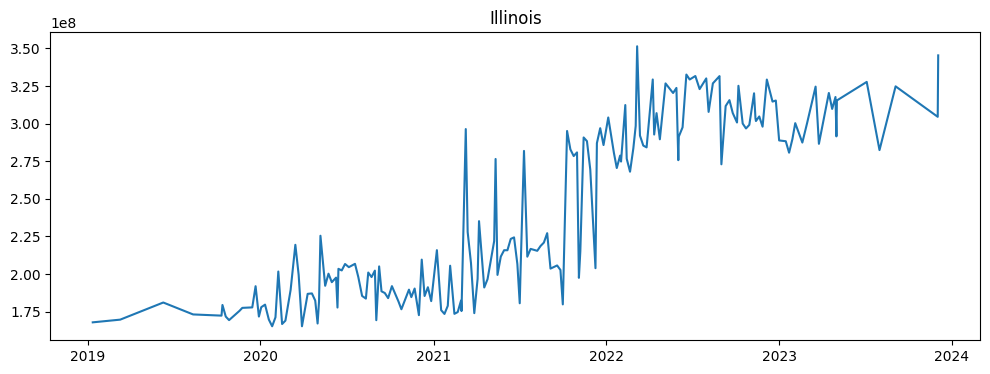

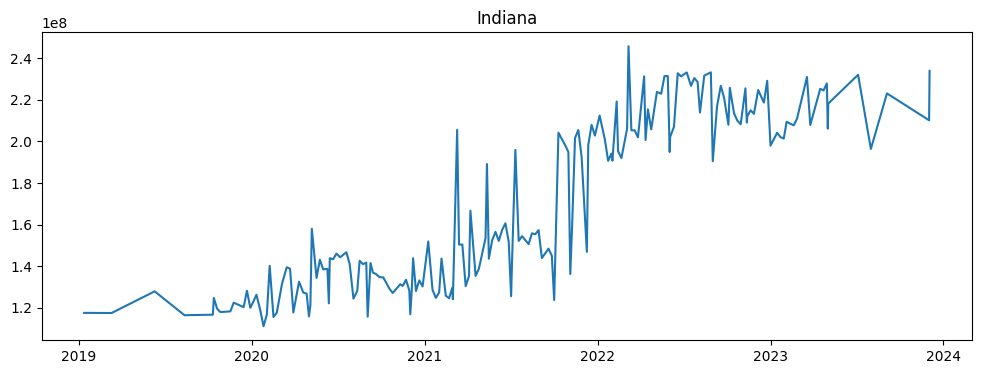

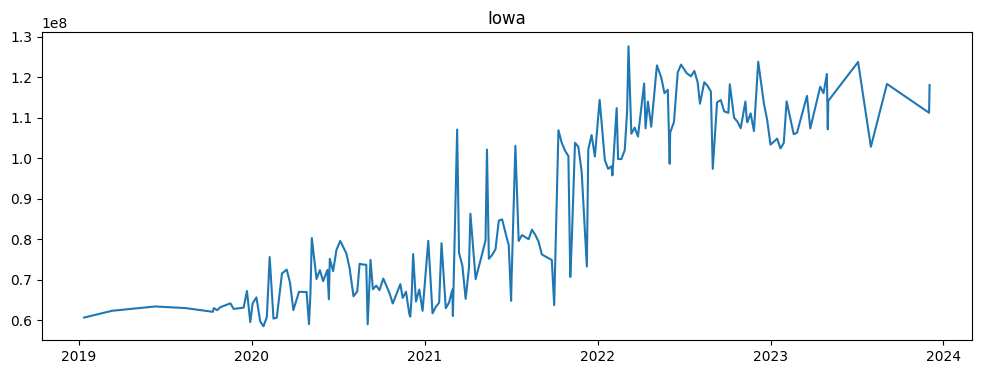

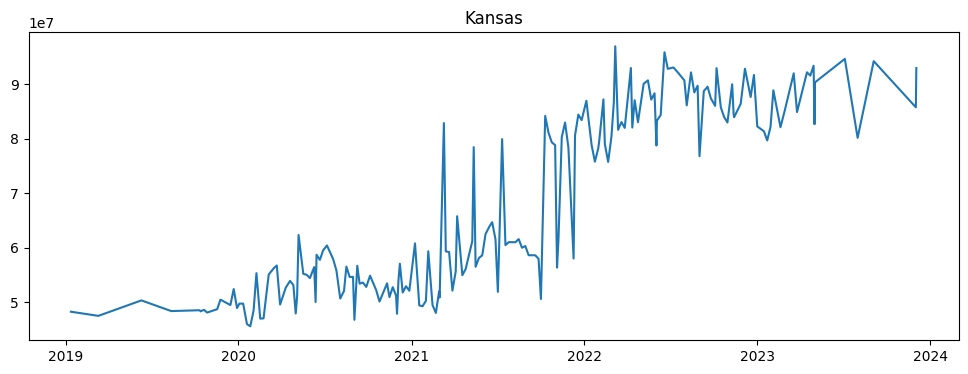

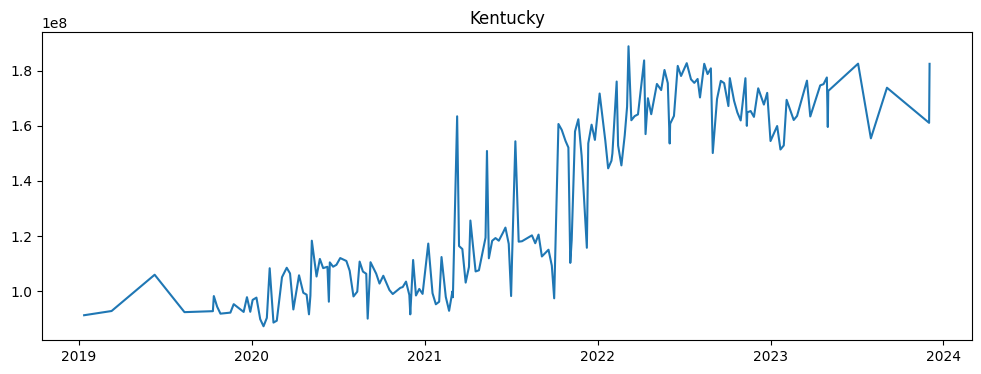

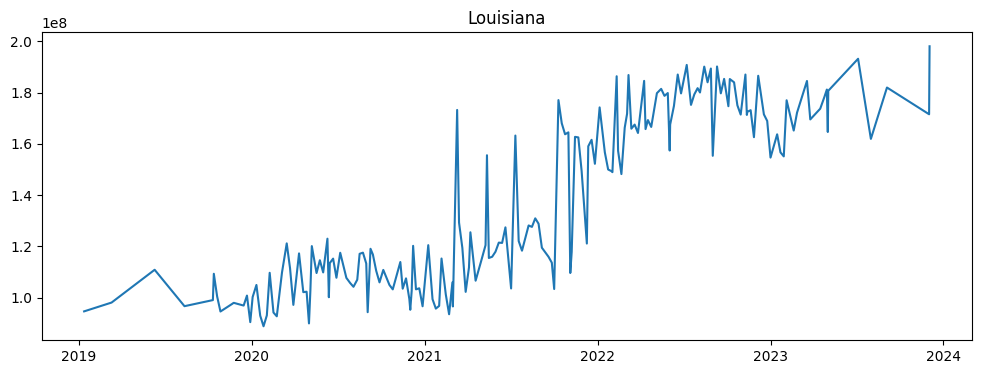

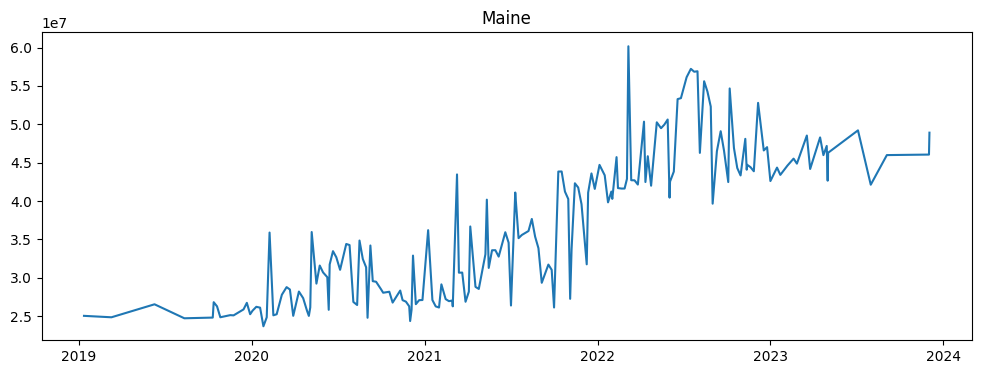

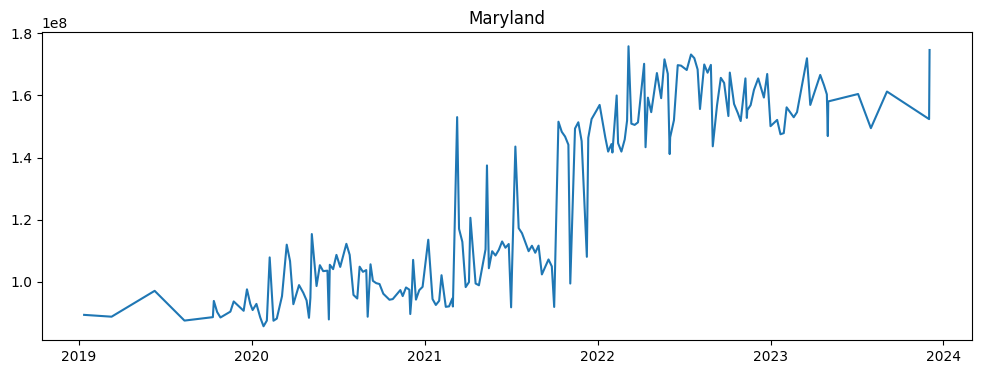

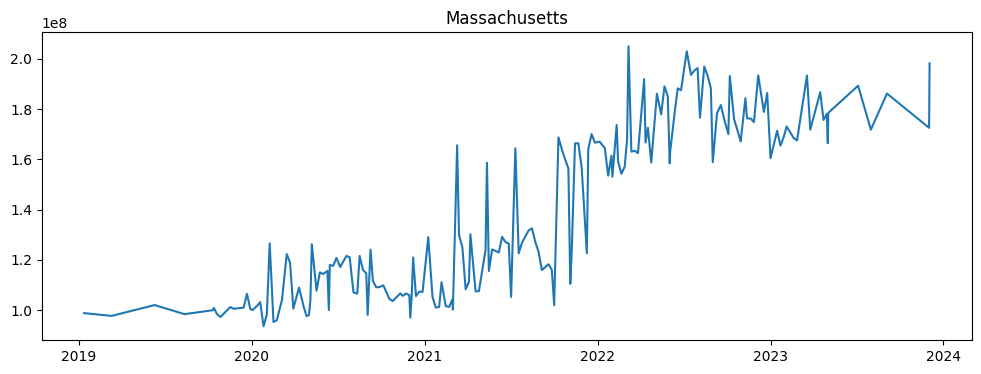

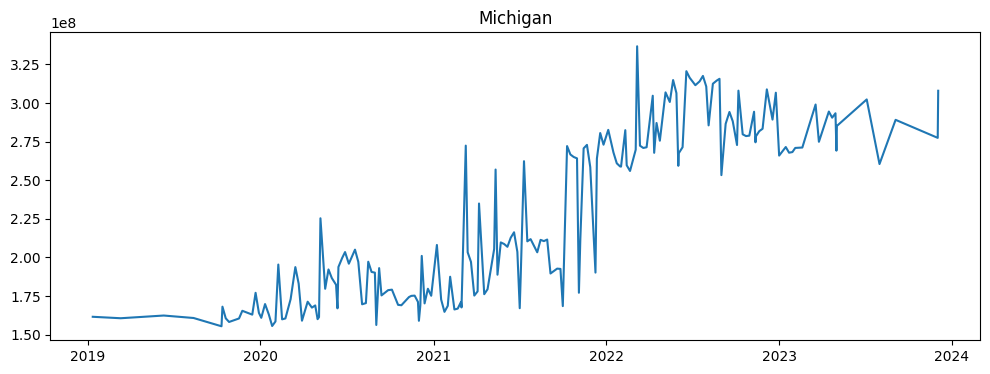

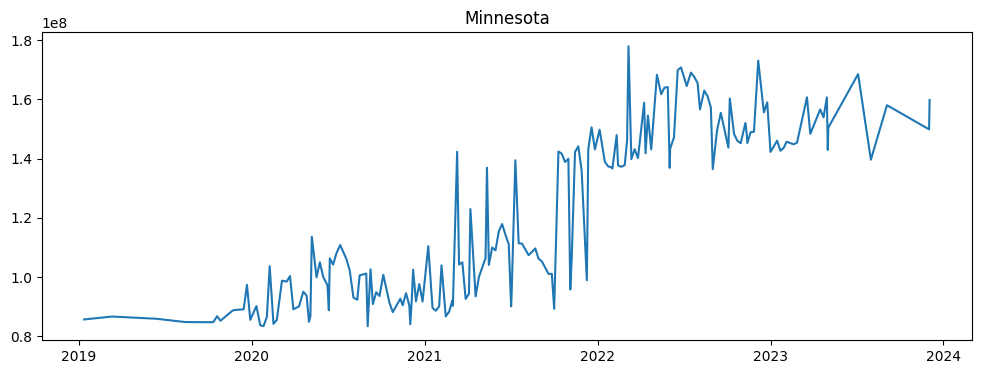

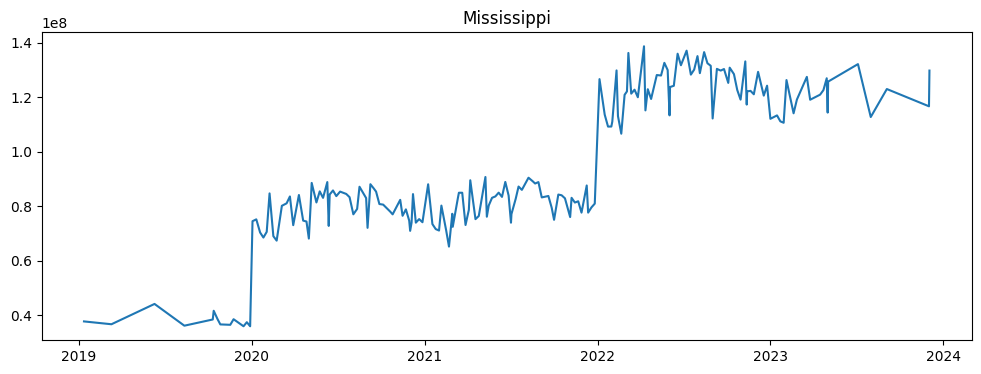

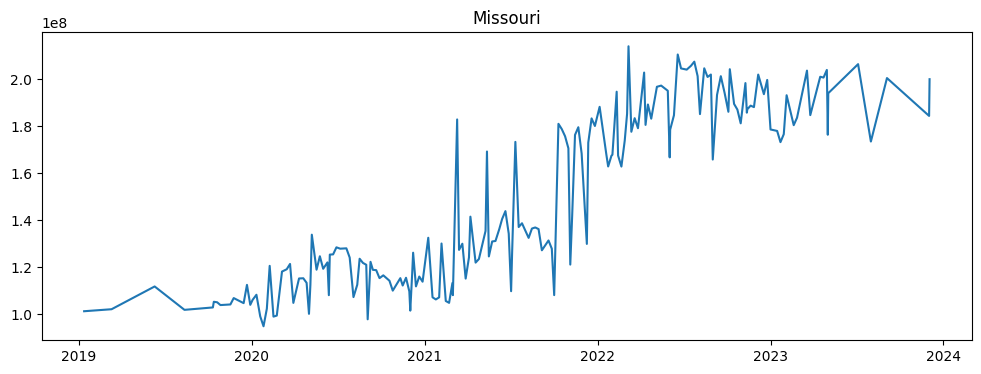

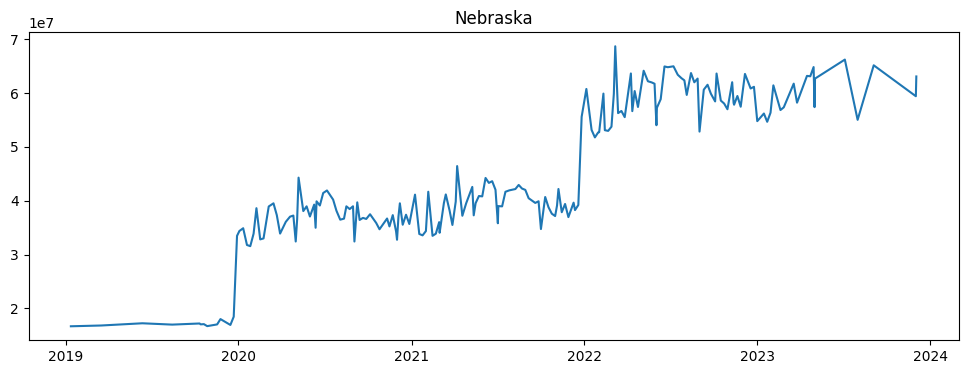

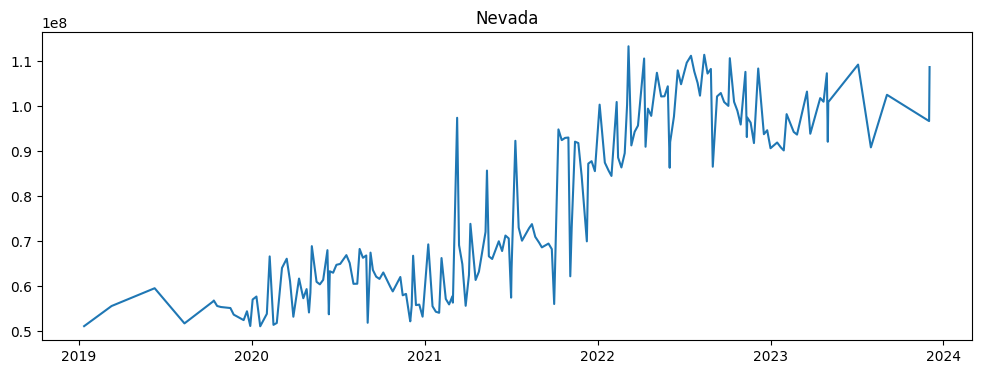

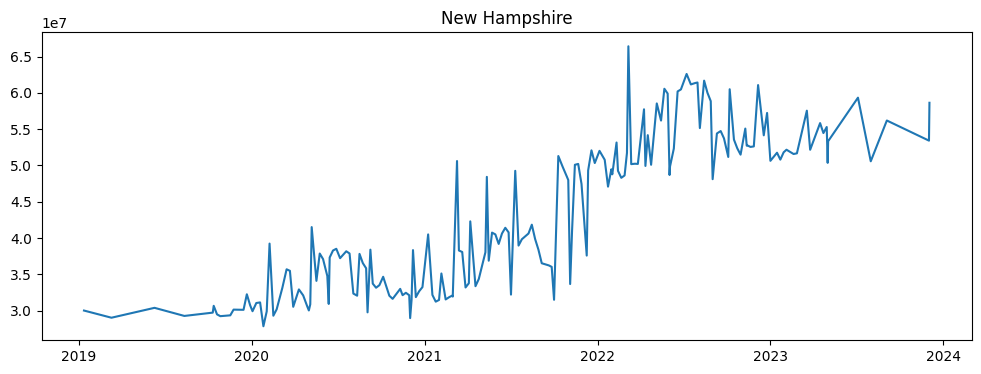

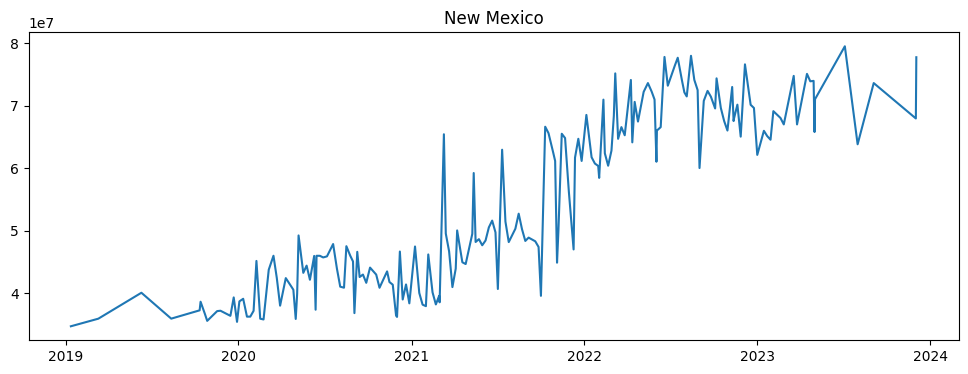

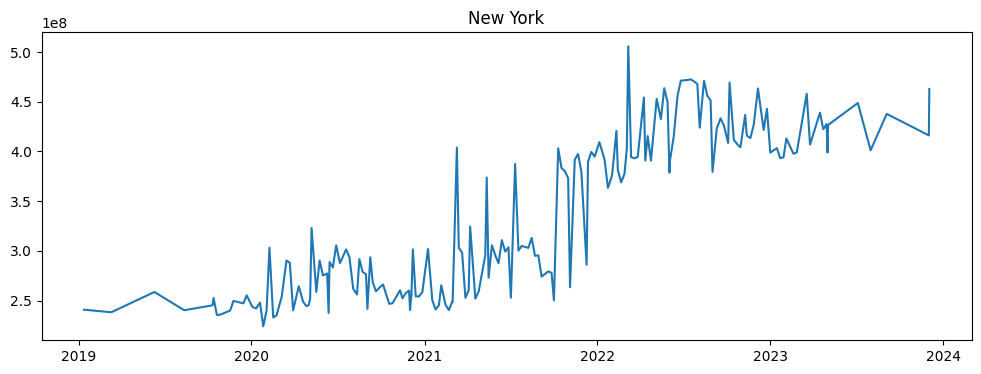

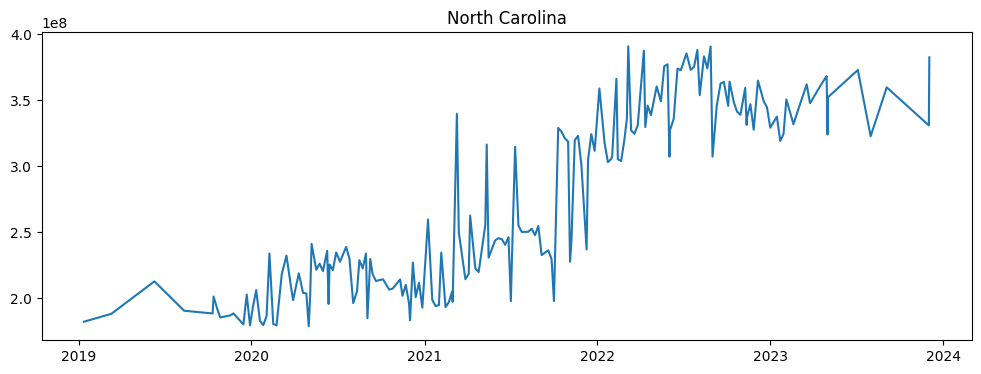

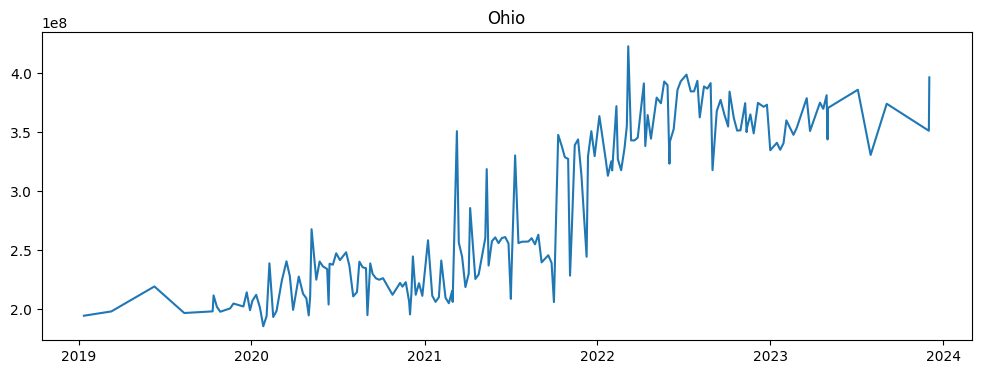

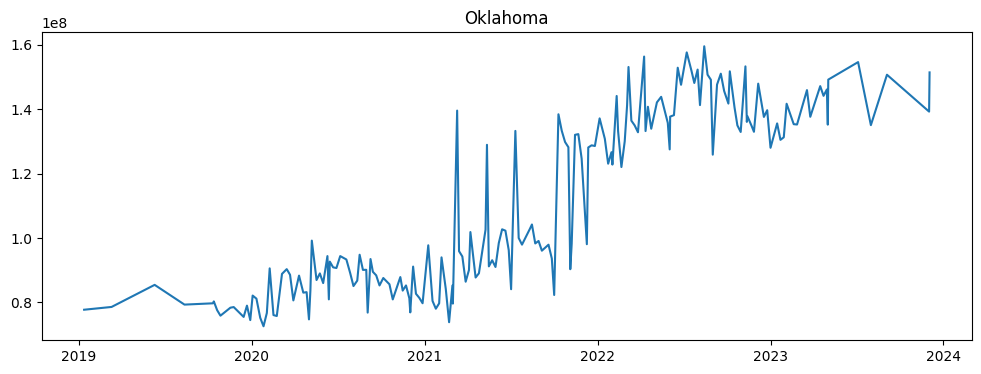

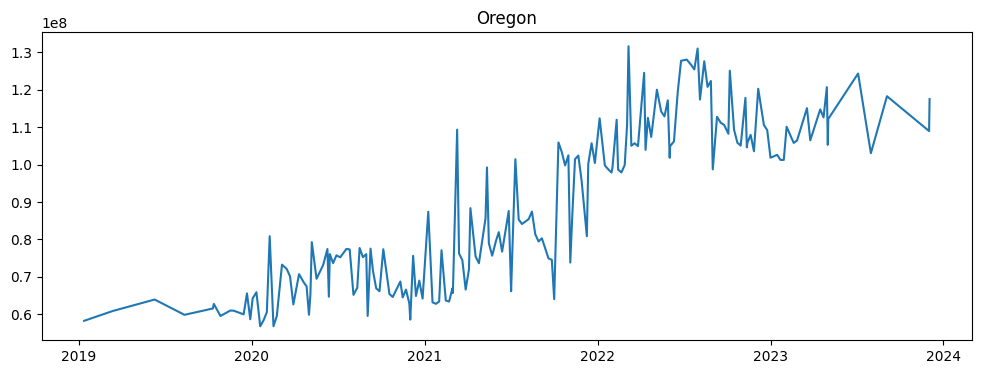

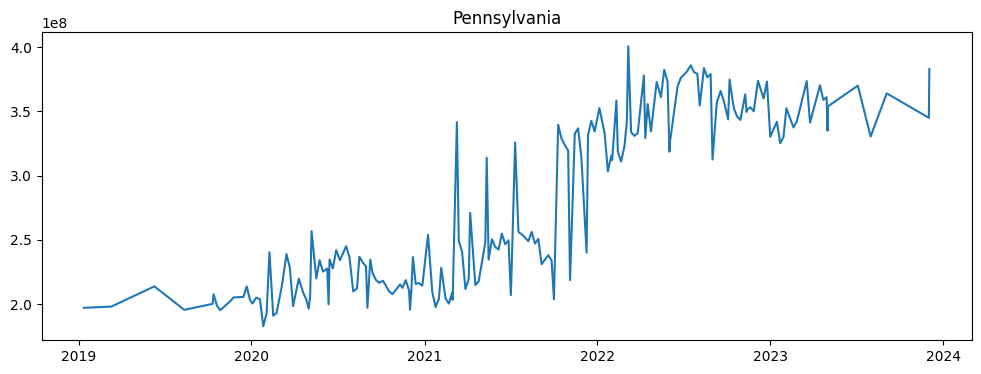

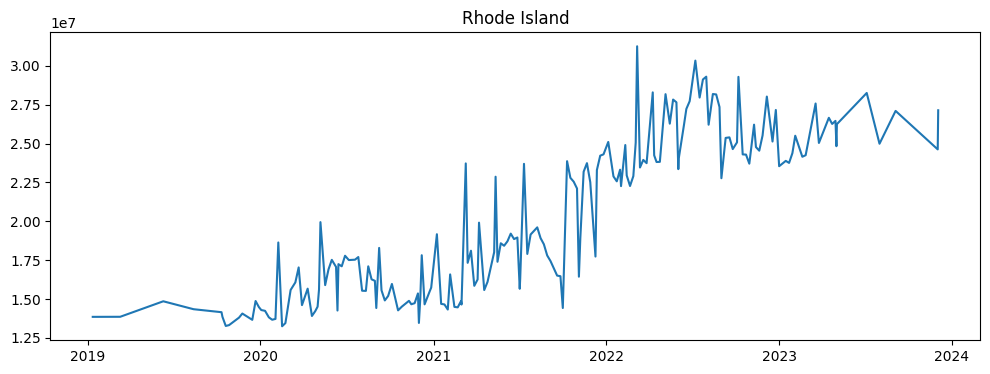

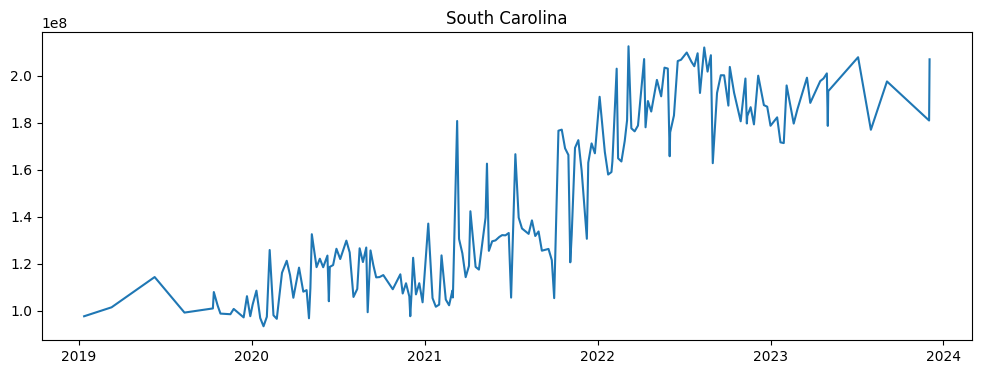

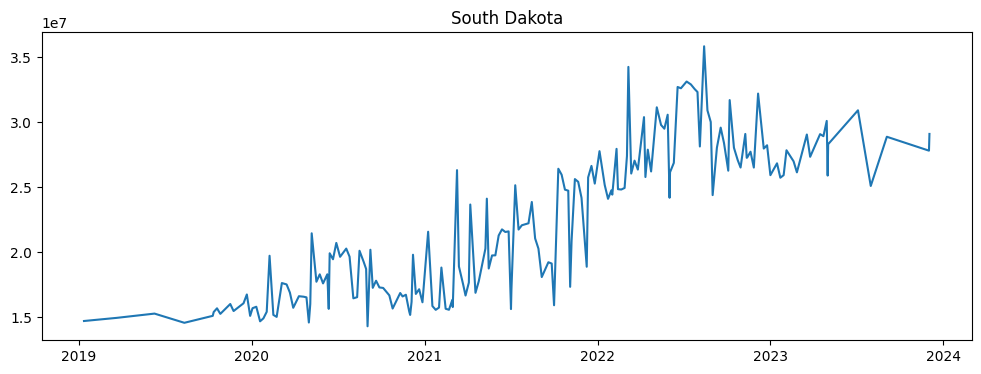

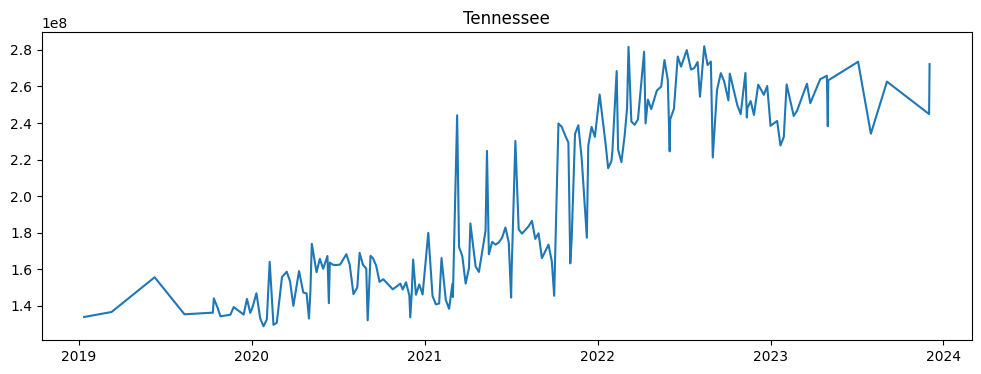

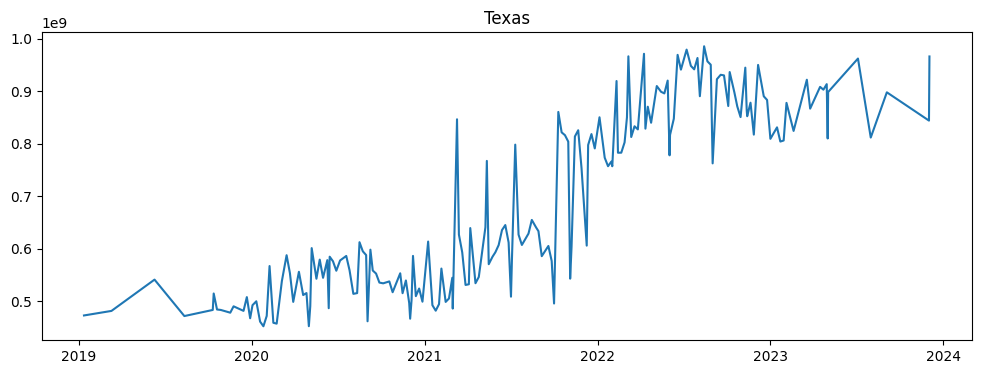

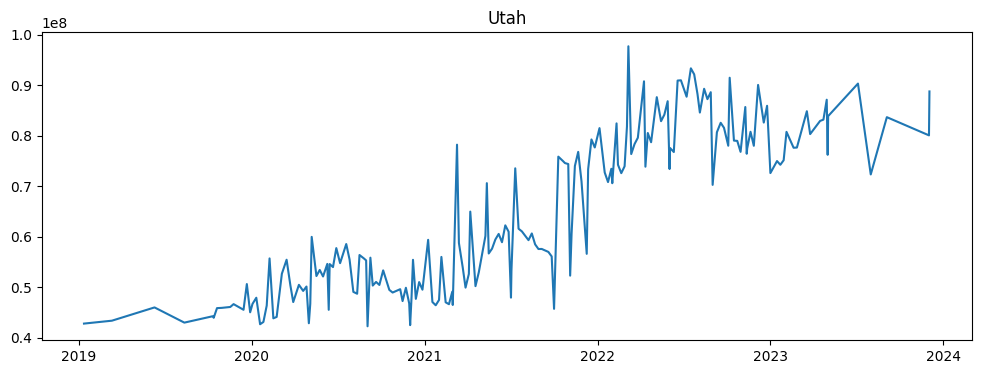

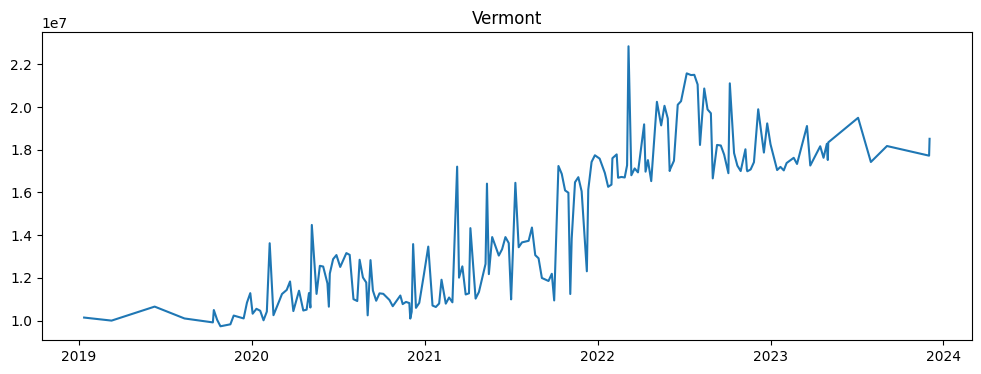

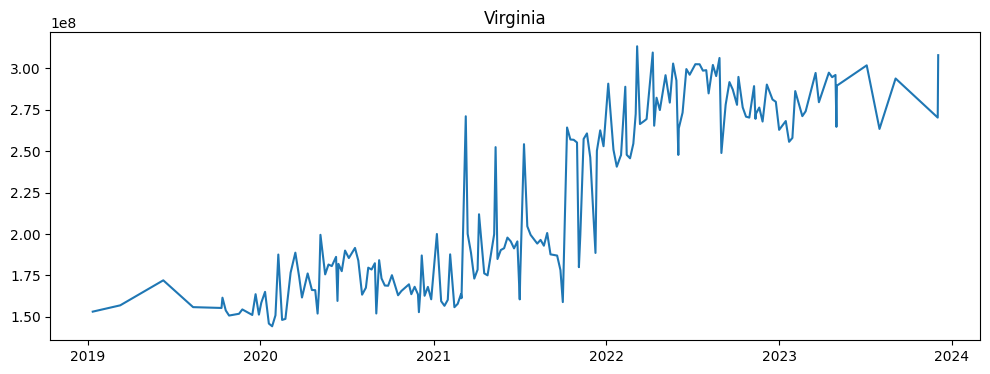

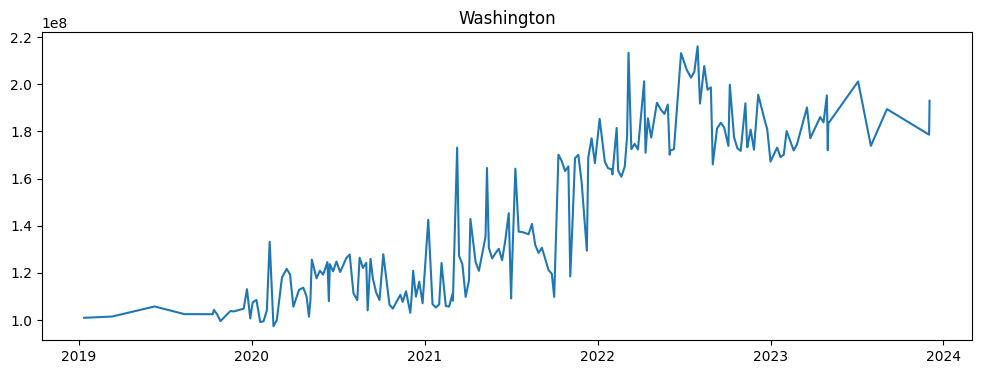

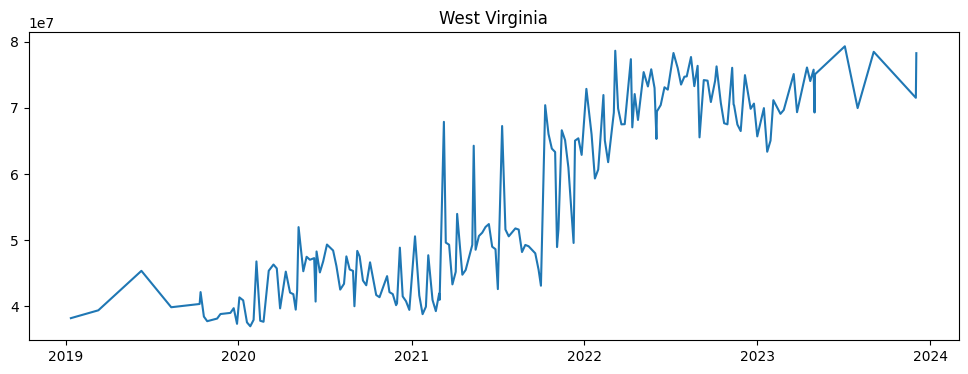

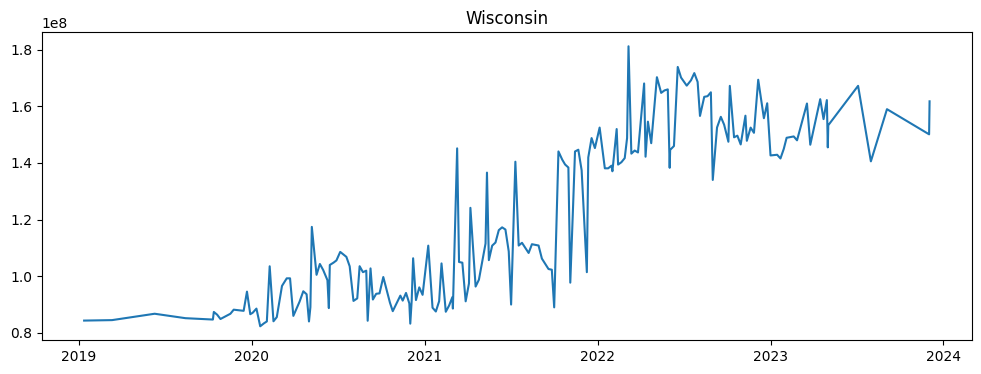

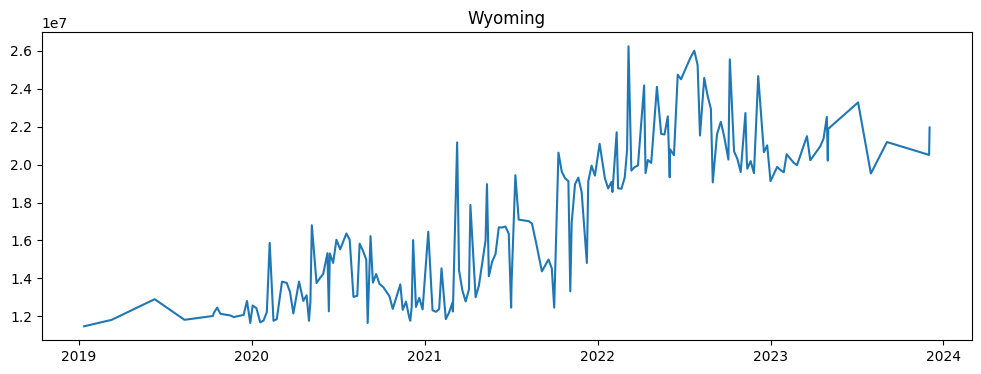

In [7]:
import matplotlib.pyplot as plt

for state in df['State'].unique():
    temp = df[df['State'] == state]

    plt.figure(figsize=(12,4))
    plt.plot(temp['Date'], temp['Total'])
    plt.title(state)
    plt.show()

**STEP 4 - Feature Engineering**

Lag Features

In [8]:
lags = [1, 7, 30]

for lag in lags:
    df[f'lag_{lag}'] = df.groupby('State')['Total'].shift(lag)

Rolling Features

In [9]:
windows = [7, 30]

for window in windows:
    df[f'rolling_mean_{window}'] = (
        df.groupby('State')['Total']
        .shift(1)
        .rolling(window)
        .mean()
    )

    df[f'rolling_std_{window}'] = (
        df.groupby('State')['Total']
        .shift(1)
        .rolling(window)
        .std()
    )

Date Features

In [10]:
df['day_of_week'] = df['Date'].dt.dayofweek

df['month'] = df['Date'].dt.month

df['week'] = df['Date'].dt.isocalendar().week

Holiday Feature

In [11]:
import holidays

india_holidays = holidays.India()

df['is_holiday'] = df['Date'].apply(
    lambda x: 1 if x in india_holidays else 0
)

Remove Null Rows

In [12]:
df = df.dropna()

**STEP 5 - Train Validation Split**

In [13]:
split_date = '2023-01-01'

train = df[df['Date'] < split_date]
val = df[df['Date'] >= split_date]

**STEP 6 - Model 1: ARIMA / SARIMA**

In [14]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 9.9 MB/s eta 0:00:00


In [15]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error

unique_states = train['State'].unique()
print(f"Unique states in training data: {list(unique_states)}")

selected_state = 'Delhi'
if selected_state not in unique_states:
    print(f"Warning: '{selected_state}' not found in training data. Using '{unique_states[0]}' instead.")
    selected_state = unique_states[0]

state_df = train[train['State'] == selected_state].set_index('Date') # Set 'Date' as index here

print(f"Shape of '{selected_state}' state_df: {state_df.shape}")

# Note: The validation set (val) is currently empty due to a late split_date.
# Adjust split_date to an earlier value if you need a non-empty validation set.

model = SARIMAX(
    state_df['Total'],
    order=(1,1,1),
    seasonal_order=(1,1,1,7)
)

result = model.fit()

forecast = result.forecast(steps=56)


Unique states in training data: ['Alabama', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Florida', 'Georgia', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Nebraska', 'Nevada', 'New Hampshire', 'New Mexico', 'New York', 'North Carolina', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']
Shape of 'Alabama' state_df: (1420, 14)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


**STEP 7 - Model 2: Facebook Prophet**

In [16]:
!pip install prophet

In [17]:
from prophet import Prophet

prophet_df = state_df.reset_index()[['Date', 'Total']]
prophet_df.columns = ['ds', 'y']

model = Prophet()
model.fit(prophet_df)

future = model.make_future_dataframe(periods=56)
forecast = model.predict(future)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


**STEP 8 - Model 3: XGBoost**

In [18]:
!pip install xgboost

In [19]:
from xgboost import XGBRegressor

features = [
    'lag_1',
    'lag_7',
    'lag_30',
    'rolling_mean_7',
    'rolling_std_7',
    'day_of_week',
    'month',
    'is_holiday'
]

X_train = train[features]
y_train = train['Total']

X_val = val[features]
y_val = val['Total']

model = XGBRegressor()
model.fit(X_train, y_train)

preds = model.predict(X_val)

**STEP 9 - Model 4: LSTM**

Scaling

In [20]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled = scaler.fit_transform(df[['Total']])

Sequence Creation

In [21]:
import numpy as np


def create_sequences(data, seq_length=30):
    X = []
    y = []

    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i])
        y.append(data[i])

    return np.array(X), np.array(y)


X, y = create_sequences(scaled)

LSTM Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

lstm_model = Sequential([
    LSTM(64, activation='relu', input_shape=(X.shape[1], X.shape[2])),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')

lstm_model.fit(X, y, epochs=20, batch_size=32)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
2361/2361 ━━━━━━━━━━━━━━━━━━━━ 42s 16ms/step - loss: 4.7655e-04
Epoch 2/20
2361/2361 ━━━━━━━━━━━━━━━━━━━━ 35s 15ms/step - loss: 9.9649e-05
Epoch 3/20
2361/2361 ━━━━━━━━━━━━━━━━━━━━ 36s 15ms/step - loss: 7.9237e-05
Epoch 4/20
2361/2361 ━━━━━━━━━━━━━━━━━━━━ 36s 15ms/step - loss: 7.2319e-05
Epoch 5/20
2361/2361 ━━━━━━━━━━━━━━━━━━━━ 36s 15ms/step - loss: 6.7576e-05
Epoch 6/20
2361/2361 ━━━━━━━━━━━━━━━━━━━━ 42s 16ms/step - loss: 6.3890e-05
Epoch 7/20
2361/2361 ━━━━━━━━━━━━━━━━━━━━ 37s 16ms/step - loss: 6.3350e-05
Epoch 8/20
2361/2361 ━━━━━━━━━━━━━━━━━━━━ 35s 15ms/step - loss: 6.2517e-05
Epoch 9/20
2361/2361 ━━━━━━━━━━━━━━━━━━━━ 36s 15ms/step - loss: 6.3496e-05
Epoch 10/20
2361/2361 ━━━━━━━━━━━━━━━━━━━━ 36s 15ms/step - loss: 6.1601e-05
Epoch 11/20
2361/2361 ━━━━━━━━━━━━━━━━━━━━ 35s 15ms/step - loss: 6.0175e-05
Epoch 12/20
2361/2361 ━━━━━━━━━━━━━━━━━━━━ 36s 15ms/step - loss: 6.0807e-05
Epoch 13/20
2361/2361 ━━━━━━━━━━━━━━━━━━━━ 36s 15ms/step - loss: 5.9594e-05
Epoch 14/20
2361/2361

**STEP 10 - Model Evaluation**

In [22]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

mae = mean_absolute_error(y_val, preds)

rmse = np.sqrt(mean_squared_error(y_val, preds))

mape = np.mean(np.abs((y_val - preds) / y_val)) * 100

print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'Mean Absolute Percentage Error (MAPE): {mape:.2f}%')

Mean Absolute Error (MAE): 2211615.59
Root Mean Squared Error (RMSE): 5730240.43
Mean Absolute Percentage Error (MAPE): 0.85%


Select best model

In [23]:
import pandas as pd

# Creating a DataFrame to store model results
results = pd.DataFrame({
    'Model': ['XGBoost'], # Adding other model names as they are evaluated
    'RMSE': [rmse] # Collecting RMSE from other models here as well
})

best_model = results.sort_values('RMSE').iloc[0]

**STEP 11 - Save Best Model**

In [24]:
import joblib

joblib.dump(model, 'best_model.pkl')

['best_model.pkl']

Download Cleaned Dataset

In [29]:
df.to_csv("cleaned_sales_data.csv", index=False)

In [30]:
from google.colab import files
files.download("cleaned_sales_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>